# SDS-PAGE — Protein Molecular Weight Estimation

**Technique:** SDS-Polyacrylamide Gel Electrophoresis (SDS-PAGE)
**Objective:** Build a standard curve from protein ladder migration distances
and use it to estimate the molecular weight of unknown protein bands.

---
## 1. Background

SDS denatures proteins and coats them with a uniform negative charge proportional
to mass. Under an electric field, smaller proteins migrate further through the
polyacrylamide gel than larger ones. For ladder standards, migration distance is
linearly related to **log10(molecular weight)** — this relationship (the standard
curve) is used to estimate the size of unknown protein bands.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("sample_data/migration_distances.csv")
df

,band_id,type,migration_mm,known_mw_kda
0,Ladder_1,ladder,12.0,180.0
1,Ladder_2,ladder,18.5,130.0
2,Ladder_3,ladder,25.0,100.0
3,Ladder_4,ladder,33.0,70.0
4,Ladder_5,ladder,42.0,55.0
5,Ladder_6,ladder,55.0,35.0
6,Ladder_7,ladder,68.0,25.0
7,Ladder_8,ladder,80.0,15.0
8,Unknown_1,sample,38.5,NaN
9,Unknown_2,sample,52.1,NaN


## 2. Fit the standard curve from ladder bands

In [2]:
ladder = df[df.type == "ladder"].copy()
ladder["log_mw"] = np.log10(ladder.known_mw_kda)

m, b = np.polyfit(ladder.migration_mm, ladder.log_mw, 1)

predicted = m * ladder.migration_mm + b
ss_res = np.sum((ladder.log_mw - predicted) ** 2)
ss_tot = np.sum((ladder.log_mw - ladder.log_mw.mean()) ** 2)
r_squared = 1 - ss_res / ss_tot

print(f"Standard curve: log10(MW) = {m:.4f} * distance + {b:.3f}")
print(f"R² = {r_squared:.3f}")

Standard curve: log10(MW) = -0.0152 * distance + 2.392
R² = 0.994


## 3. Estimate molecular weight of unknown bands

In [3]:
unknowns = df[df.type == "sample"].copy()
unknowns["estimated_mw_kda"] = 10 ** (m * unknowns.migration_mm + b)
unknowns[["band_id", "migration_mm", "estimated_mw_kda"]].round(1)

,band_id,migration_mm,estimated_mw_kda
8,Unknown_1,38.5,64.2
9,Unknown_2,52.1,39.9


## 4. Visualise the standard curve

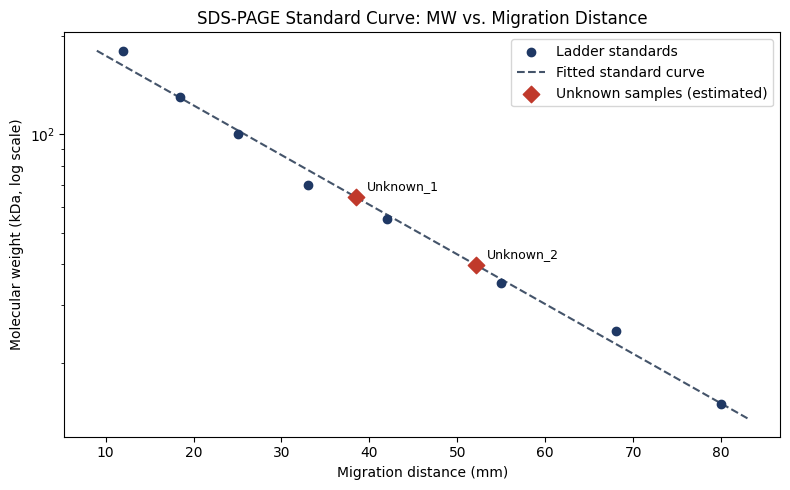

In [4]:
x_fit = np.linspace(ladder.migration_mm.min() - 3, ladder.migration_mm.max() + 3, 100)
y_fit = 10 ** (m * x_fit + b)

plt.figure(figsize=(8, 5))
plt.scatter(ladder.migration_mm, ladder.known_mw_kda, color="#1F3864", label="Ladder standards", zorder=3)
plt.plot(x_fit, y_fit, color="#44546A", linestyle="--", label="Fitted standard curve", zorder=2)
plt.scatter(unknowns.migration_mm, unknowns.estimated_mw_kda, color="#C0392B", marker="D", s=70,
            label="Unknown samples (estimated)", zorder=4)

for _, row in unknowns.iterrows():
    plt.annotate(row.band_id, (row.migration_mm, row.estimated_mw_kda),
                 textcoords="offset points", xytext=(8, 5), fontsize=9)

plt.yscale("log")
plt.xlabel("Migration distance (mm)")
plt.ylabel("Molecular weight (kDa, log scale)")
plt.title("SDS-PAGE Standard Curve: MW vs. Migration Distance")
plt.legend()
plt.tight_layout()
plt.savefig("sds_page_standard_curve.png", dpi=150)
plt.show()

## 5. Summary

The fitted standard curve allows estimation of unknown protein molecular weights
from measured migration distance alone. A high R² value (close to 1.0) indicates
a reliable curve fit across the ladder range; estimates for unknown bands falling
outside the ladder's migration range should be treated as extrapolations and
interpreted with caution.
